# Task 1
Дослідіть вплив функцій активації на результати моделі.
* Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
* Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
* Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
* Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
* Оформіть результати в таблиці:

In [1]:
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1, 1) * 0.01
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1) * 0.01
xtrain[:5]

tensor([[ 2.0467e+00, -6.1205e-01,  3.1233e-02, -2.0451e+00,  8.2476e-01,
         -5.4752e-01, -4.2994e-01,  1.6689e+00, -7.4672e-01, -5.6026e-02],
        [ 5.5781e-01, -2.5538e-01, -3.3439e-01, -6.4515e-01,  6.4901e-01,
         -1.1773e+00, -9.7106e-01,  1.4197e+00,  4.5510e-01, -1.1275e+00],
        [-1.0840e+00, -4.3829e-01,  2.0512e-01, -1.6644e+00,  5.1398e-01,
         -1.7696e+00, -3.6944e-01, -3.7216e-02,  1.0475e+00, -1.1638e+00],
        [ 6.0935e-01, -9.5839e-01, -1.1053e+00, -1.3801e-02,  1.1771e+00,
         -9.8595e-01, -9.0824e-05, -1.6677e+00,  1.7617e+00, -1.3259e+00],
        [ 4.3229e-01,  1.5483e-01, -6.2643e-02, -1.7735e+00,  1.0397e+00,
          5.4180e-01,  7.8911e-01, -1.3439e+00,  6.2930e-01,  4.4060e-01]])

In [3]:
import torch.nn as nn
activators = {
    'Sigmoid': nn.Sigmoid(),
    'ReLU': nn.ReLU(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU(),
    'SiLU': nn.SiLU(),
    'Swish': nn.SiLU(),
}

In [4]:
class Mlp(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activation='ReLU'):
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None:
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )
    def forward(self, x):
        return self.layers(x)

In [14]:
def train_model(model, X, y, epochs=1000, lr=0.01):
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs):
        output = model(X)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses

In [15]:
mlps = {k: Mlp(activation=k) for k in activators.keys()}
mlps

{'Sigmoid': Mlp(
   (activation): Sigmoid()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Sigmoid()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'ReLU': Mlp(
   (activation): ReLU()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'Tanh': Mlp(
   (activation): Tanh()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Tanh()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'LeakyReLU': Mlp(
   (activation): LeakyReLU(negative_slope=0.01)
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): LeakyReLU(negative_slope=0.01)
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'SiLU': Mlp(
   (activation): SiLU()
   (layers): Sequential(
     (0): Linear(in_features=10, ou

In [16]:
losses = {}
predictions = {}
for k, mlp in mlps.items():
    losses[k] = train_model(mlp, xtrain, ytrain)
    with torch.no_grad():
        predictions[k] = mlp(xtest)

print(*zip(*(predictions[k][:5] for k in mlps.keys() ), ytest[:5]), sep='\n')

(tensor([0.8046]), tensor([0.8597]), tensor([0.8392]), tensor([0.8234]), tensor([0.7895]), tensor([0.7222]), tensor([0.5646]))
(tensor([1.7568]), tensor([1.5784]), tensor([1.7507]), tensor([1.6152]), tensor([1.6758]), tensor([1.7146]), tensor([1.8919]))
(tensor([1.1707]), tensor([1.0947]), tensor([1.2213]), tensor([1.2245]), tensor([1.0095]), tensor([1.1136]), tensor([1.0568]))
(tensor([2.1182]), tensor([1.9953]), tensor([1.9872]), tensor([2.1329]), tensor([2.0019]), tensor([2.0630]), tensor([2.0647]))
(tensor([1.6633]), tensor([1.5762]), tensor([1.5427]), tensor([1.6572]), tensor([1.7108]), tensor([1.5653]), tensor([1.5550]))


In [21]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

md("\n".join((
    "|Activation|MAE|R²|",
    "|-|-|-|",
    *(f"|{k}|{sm.mean_absolute_error(ytest, v)}|{sm.r2_score(ytest, v)}|" for k, v in predictions.items())
)))

|Activation|MAE|R²|
|-|-|-|
|Sigmoid|0.12354777008295059|0.9920269250869751|
|ReLU|0.13128666579723358|0.9919950366020203|
|Tanh|0.1399083435535431|0.9898495674133301|
|LeakyReLU|0.1405090093612671|0.9906123876571655|
|SiLU|0.10318637639284134|0.9948362112045288|
|Swish|0.09782800823450089|0.9955208897590637|

In [18]:
import matplotlib.pyplot as plt

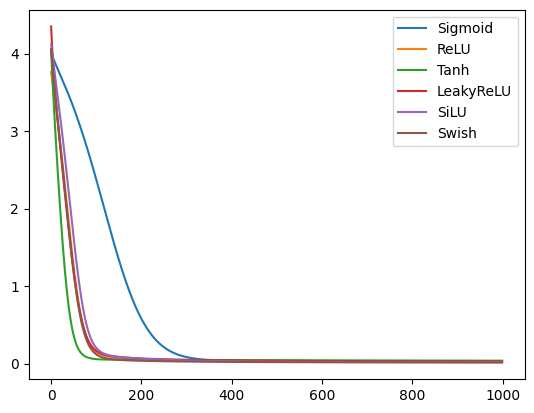

In [20]:
fig, ax = plt.subplots()
for k, v in losses.items():
    ax.plot(v, label=k)
plt.legend()
plt.show()